# Phase 3A: Linear Analysis - Granger Causality

## Objective

Test whether news sentiment **statistically predicts** stock returns using Granger Causality —> a linear, lag-based test that asks:

> *"Does knowing yesterday's sentiment help predict today's return, beyond what return history alone can tell us?"*

## Pipeline Overview

```
Phase 1: Data Preparation & Alignment
    ↓
Phase 2: Pre-Analysis Validation (ADF Stationarity Test)
    ↓
Phase 3: Granger Causality Loop (60 tickers × 2 models × 5 lags)
    ↓
Phase 4: Market Signal Control Test (Broad Market)
    ↓
Phase 5: Reporting & Visualization
    ↓
Output: granger_causality_results.csv
```

## Mathematical Foundation

**Granger Causality** tests whether time series X "Granger-causes" Y:

$$Y_t = \alpha + \sum_{i=1}^{p} \beta_i Y_{t-i} + \sum_{i=1}^{p} \gamma_i X_{t-i} + \epsilon_t$$

**Null Hypothesis ($H_0$)**: $\gamma_1 = \gamma_2 = ... = \gamma_p = 0$ (sentiment adds no predictive power)

**Reject $H_0$** if $p < 0.05$ → Sentiment Granger-causes returns

---

## 1. Setup: Imports and Paths

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import statsmodels.api as sm

import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import os
import random
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [52]:
project_root = '/content/drive/MyDrive/market-sentiment-impact-analysis'

data_processed = os.path.join(project_root, 'data', 'processed')
plots = os.path.join(project_root, 'plots')

print(f'Project Root: {project_root}')
print(f'Processed Data: {data_processed}')
print(f'Plots: {plots}')

Project Root: /content/drive/MyDrive/market-sentiment-impact-analysis
Processed Data: /content/drive/MyDrive/market-sentiment-impact-analysis/data/processed
Plots: /content/drive/MyDrive/market-sentiment-impact-analysis/plots


---

## 2: Data Preparation & Alignment

### 2.1 Load Data

In [4]:
stock_returns = pd.read_csv(os.path.join(data_processed, 'stock_returns_60.csv'))
stock_returns['Date'] = pd.to_datetime(stock_returns['Date'])

print('Stock returns loaded:')
print(f'  Shape: {stock_returns.shape}')
print(f'  Date range: {stock_returns['Date'].min().date()} to {stock_returns['Date'].max().date()}')
print(f'  Unique tickers: {stock_returns['Ticker'].nunique()}')
print(f'  Columns: {list(stock_returns.columns)}')

Stock returns loaded:
  Shape: (38340, 6)
  Date range: 2018-01-03 to 2020-07-17
  Unique tickers: 60
  Columns: ['Date', 'Ticker', 'Log_Return', 'Sector', 'Beta', 'Beta_Group']


In [5]:
sentiment = pd.read_csv(os.path.join(data_processed, 'sentiment_scores_60.csv'))
sentiment['date'] = pd.to_datetime(sentiment['date'])

print(f'Sentiment scores loaded:')
print(f'  Shape: {sentiment.shape}')
print(f'  Date range: {sentiment['date'].min().date()} to {sentiment['date'].max().date()}')
print(f'  Unique tickers: {sentiment['Ticker'].nunique()}')
print(f'  Columns: {list(sentiment.columns)}')

Sentiment scores loaded:
  Shape: (44723, 7)
  Date range: 2018-01-02 to 2020-07-18
  Unique tickers: 60
  Columns: ['date', 'Ticker', 'vader_mean', 'vader_std', 'article_count', 'finbert_mean', 'finbert_std']


In [6]:
market_sentiment = pd.read_csv(os.path.join(data_processed, 'market_sentiment_general.csv'))
market_sentiment['date'] = pd.to_datetime(market_sentiment['date'])

print(f'Market sentiment loaded:')
print(f'  Shape: {market_sentiment.shape}')
print(f'  Date range: {market_sentiment['date'].min().date()} to {market_sentiment['date'].max().date()}')
print(f'  Columns: {list(market_sentiment.columns)}')

Market sentiment loaded:
  Shape: (2445, 6)
  Date range: 2018-01-02 to 2020-07-18
  Columns: ['date', 'market_vader_mean', 'market_vader_std', 'market_article_count', 'market_finbert_mean', 'market_finbert_std']


### 2.2 Weekend Handling

**Problem**: News is published 7 days a week, but stock markets only trade Monday-Friday.

Weekend news (Saturday/Sunday) has **pent-up** informational value that materializes on Monday morning's open. A naive merge would lose this signal entirely.

**Solution**: Map Saturday → Monday, Sunday → Monday, then re-aggregate.

**Monday's Aggregated Signal**:
$$S_{Monday} = \frac{N_{Sat} \cdot \bar{s}_{Sat} + N_{Sun} \cdot \bar{s}_{Sun} + N_{Mon} \cdot \bar{s}_{Mon}}{N_{Sat} + N_{Sun} + N_{Mon}}$$

Re-aggregation uses mean of means, which is appropriate when articles have equal weight.

In [7]:
def map_to_next_trading_day(date_series):
    """
    Map Saturday and Sunday dates to the following Monday.
    Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
    """
    day_of_week = date_series.dt.dayofweek

    days_to_add = pd.Series(0, index=date_series.index)
    days_to_add[day_of_week == 5] = 2
    days_to_add[day_of_week == 6] = 1

    return date_series + pd.to_timedelta(days_to_add, unit='D')

weekend_mask = sentiment['date'].dt.dayofweek >= 5
print('Weekend news in sentiment data:')
print(f'  Saturday/Sunday articles: {weekend_mask.sum():,} ({weekend_mask.sum()/len(sentiment)*100:.1f}%)')
print(f'  Weekday articles: {(~weekend_mask).sum():,}')

sentiment['date'] = map_to_next_trading_day(sentiment['date'])

weekend_mask_mkt = market_sentiment['date'].dt.dayofweek >= 5
print('\nWeekend news in market sentiment:')
print(f'  Saturday/Sunday articles: {weekend_mask_mkt.sum():,}')
market_sentiment['date'] = map_to_next_trading_day(market_sentiment['date'])

print('\n  Weekend dates mapped to next Monday')

Weekend news in sentiment data:
  Saturday/Sunday articles: 6,297 (14.1%)
  Weekday articles: 38,426

Weekend news in market sentiment:
  Saturday/Sunday articles: 254

  Weekend dates mapped to next Monday


In [8]:
# Re-aggregate sentiment after date mapping
# Saturday + Sunday + Monday news now all aggregate into Monday

sentiment = sentiment.groupby(['date', 'Ticker']).agg({
    'vader_mean': 'mean',
    'finbert_mean': 'mean',
    'article_count': 'sum',
    'vader_std': 'mean',
    'finbert_std': 'mean'
}).reset_index()

market_sentiment = market_sentiment.groupby('date').agg({
    'market_vader_mean': 'mean',
    'market_finbert_mean': 'mean',
    'market_article_count': 'sum',
    'market_vader_std': 'mean',
    'market_finbert_std': 'mean'
}).reset_index()

print('After weekend re-aggregation:')
print(f'  Sentiment rows: {len(sentiment):,}')
print(f'  Market sentiment rows: {len(market_sentiment):,}')

remaining_weekends = (sentiment['date'].dt.dayofweek >= 5).sum()
print(f'  Remaining weekend dates: {remaining_weekends}')

After weekend re-aggregation:
  Sentiment rows: 39,213
  Market sentiment rows: 2,206
  Remaining weekend dates: 0


### 2.3 Master DataFrame

In [9]:
sentiment.rename(columns={'date': 'Date'}, inplace=True)
market_sentiment.rename(columns={'date': 'Date'}, inplace=True)

sentiment['Date'] = sentiment['Date'].dt.tz_localize(None)

# Left join: stock returns (left) + ticker sentiment (right)
master_df = stock_returns.merge(
    sentiment,
    on=['Date', 'Ticker'],
    how='left'
)

print('After stock_returns + sentiment merge:')
print(f'  Shape: {master_df.shape}')
print(f'  NaN in vader_mean: {master_df['vader_mean'].isna().sum():,}')
print(f'  NaN in finbert_mean: {master_df['finbert_mean'].isna().sum():,}')

After stock_returns + sentiment merge:
  Shape: (38340, 11)
  NaN in vader_mean: 6,554
  NaN in finbert_mean: 6,554


In [10]:
# Impute NaN with 0.0 (neutral) -> No news = no new information = neutral sentiment signal
sentiment_cols = ['vader_mean', 'finbert_mean', 'article_count', 'vader_std', 'finbert_std']
master_df[sentiment_cols] = master_df[sentiment_cols].fillna(0.0)

print('After neutral imputation:')
print(f'  Remaining NaN in vader_mean: {master_df['vader_mean'].isna().sum()}')
print(f'  Remaining NaN in finbert_mean: {master_df['finbert_mean'].isna().sum()}')

no_news_pct = (master_df['article_count'] == 0).sum() / len(master_df) * 100
print(f'\n  Trading days with no news: {(master_df['article_count'] == 0).sum():,} ({no_news_pct:.1f}%)')
print(f'  Trading days with news: {(master_df['article_count'] > 0).sum():,} ({100 - no_news_pct:.1f}%)')

After neutral imputation:
  Remaining NaN in vader_mean: 0
  Remaining NaN in finbert_mean: 0

  Trading days with no news: 6,554 (17.1%)
  Trading days with news: 31,786 (82.9%)


In [11]:
master_df['Date'] = master_df['Date'].dt.tz_localize(None)
market_sentiment['Date'] = market_sentiment['Date'].dt.tz_localize(None)

master_df = master_df.merge(
    market_sentiment,
    on='Date',
    how='left'
)

market_cols = ['market_vader_mean', 'market_finbert_mean', 'market_article_count',
               'market_vader_std', 'market_finbert_std']
master_df[market_cols] = master_df[market_cols].fillna(0.0)

print('Master DataFrame:')
print(f'  Shape: {master_df.shape}')
print(f'  Columns: {list(master_df.columns)}')
print(f'  Date range: {master_df['Date'].min().date()} to {master_df['Date'].max().date()}')
print(f'  Unique tickers: {master_df['Ticker'].nunique()}')
print(f'  Remaining NaN anywhere: {master_df.isna().sum().sum()}')
print(f'\nSample rows:')
print(master_df.head())

Master DataFrame:
  Shape: (38340, 16)
  Columns: ['Date', 'Ticker', 'Log_Return', 'Sector', 'Beta', 'Beta_Group', 'vader_mean', 'finbert_mean', 'article_count', 'vader_std', 'finbert_std', 'market_vader_mean', 'market_finbert_mean', 'market_article_count', 'market_vader_std', 'market_finbert_std']
  Date range: 2018-01-03 to 2020-07-17
  Unique tickers: 60
  Remaining NaN anywhere: 0

Sample rows:
        Date Ticker  Log_Return       Sector   Beta Beta_Group  vader_mean  finbert_mean  article_count  vader_std  finbert_std  market_vader_mean  market_finbert_mean  market_article_count  market_vader_std  market_finbert_std
0 2018-01-03    AEP     -0.0085    Utilities 0.5856   Low Beta      0.0000        0.0000         0.0000     0.0000       0.0000             0.0651               0.1177               15.0000            0.3439              0.5988
1 2018-01-03    AMP     -0.0050   Financials 1.7709  High Beta      0.0000        0.0000         0.0000     0.0000       0.0000             0.

---

## 3. Pre-Analysis Validation

### 3.1 Stationarity Test (Augmented Dickey-Fuller)

Granger Causality assumes both time series are stationary. Running it on non-stationary series produces **spurious results**.

**ADF Test**:
- $H_0$: Series has a unit root (non-stationary)
- $p < 0.05$: Reject $H_0$ → Series is stationary

In [12]:
def run_adf_test(series, name):
    clean_series = series.dropna()

    result = adfuller(clean_series, autolag='AIC')
    stat = result[0]
    p_val = result[1]
    is_stationary = p_val < 0.05

    status = 'Stationary' if is_stationary else 'Non-Stationary'
    print(f'  {name}:')
    print(f'    ADF Statistic: {stat:.4f}')
    print(f'    p-value: {p_val:.6f}')
    print(f'    Result: {status}')

    return stat, p_val, is_stationary

random.seed(42)
sample_tickers = random.sample(list(master_df['Ticker'].unique()), 3)
print(f'Testing stationarity on 3 randomly selected tickers: {sample_tickers}')
print('='*70)

adf_results = {}

for ticker in sample_tickers:
    sub = master_df[master_df['Ticker'] == ticker].sort_values('Date')
    print(f'\nTicker: {ticker} ({len(sub)} trading days)')
    print('-'*40)

    stat_ret, p_ret, st_ret = run_adf_test(sub['Log_Return'], 'Log_Return')
    stat_vad, p_vad, st_vad = run_adf_test(sub['vader_mean'], 'vader_mean')
    stat_fin, p_fin, st_fin = run_adf_test(sub['finbert_mean'], 'finbert_mean')

    adf_results[ticker] = {
        'Log_Return_p': p_ret, 'Log_Return_stationary': st_ret,
        'vader_mean_p': p_vad, 'vader_mean_stationary': st_vad,
        'finbert_mean_p': p_fin, 'finbert_mean_stationary': st_fin
    }

Testing stationarity on 3 randomly selected tickers: ['OKE', 'CHD', 'AMP']

Ticker: OKE (639 trading days)
----------------------------------------
  Log_Return:
    ADF Statistic: -5.9061
    p-value: 0.000000
    Result: Stationary
  vader_mean:
    ADF Statistic: -10.1078
    p-value: 0.000000
    Result: Stationary
  finbert_mean:
    ADF Statistic: -15.4089
    p-value: 0.000000
    Result: Stationary

Ticker: CHD (639 trading days)
----------------------------------------
  Log_Return:
    ADF Statistic: -8.7989
    p-value: 0.000000
    Result: Stationary
  vader_mean:
    ADF Statistic: -25.0004
    p-value: 0.000000
    Result: Stationary
  finbert_mean:
    ADF Statistic: -24.2562
    p-value: 0.000000
    Result: Stationary

Ticker: AMP (639 trading days)
----------------------------------------
  Log_Return:
    ADF Statistic: -6.7054
    p-value: 0.000000
    Result: Stationary
  vader_mean:
    ADF Statistic: -16.1727
    p-value: 0.000000
    Result: Stationary
  finbert

In [13]:
print('\nStationarity Summary:')

all_returns_stationary = all(v['Log_Return_stationary'] for v in adf_results.values())
all_vader_stationary = all(v['vader_mean_stationary'] for v in adf_results.values())
all_finbert_stationary = all(v['finbert_mean_stationary'] for v in adf_results.values())

print(f'  Log_Return stationary across all tested: {all_returns_stationary}')
print(f'  vader_mean stationary across all tested: {all_vader_stationary}')
print(f'  finbert_mean stationary across all tested: {all_finbert_stationary}')

if not all_vader_stationary or not all_finbert_stationary:
    print('\n   Non-stationary sentiment detected — applying first difference as fallback')
    master_df = master_df.sort_values(['Ticker', 'Date'])
    master_df['vader_mean'] = master_df.groupby('Ticker')['vader_mean'].diff()
    master_df['finbert_mean'] = master_df.groupby('Ticker')['finbert_mean'].diff()
    master_df = master_df.dropna(subset=['vader_mean', 'finbert_mean'])
    print('    First difference applied — vader_mean and finbert_mean now represent ΔSENTIMENT')
else:
    print('\n  All series stationary')


Stationarity Summary:
  Log_Return stationary across all tested: True
  vader_mean stationary across all tested: True
  finbert_mean stationary across all tested: True

  All series stationary


- **Log Returns**: Stationary ($p \ll 0.05$). Log differencing removes unit root from prices by design.
- **Sentiment scores**: Stationary because bounded $[-1, +1]$ by construction. A bounded series cannot have an infinite variance.

---

## 4. The Granger Causality Loop

In [14]:
MAX_LAGS = 5
MIN_OBS = 50
ALPHA = 0.05

granger_results = []

unique_tickers = master_df['Ticker'].unique()
print('Granger Causality Test Configuration:')
print(f'  Tickers: {len(unique_tickers)}')
print(f'  Max lags: {MAX_LAGS} (trading days)')
print(f'  Minimum observations: {MIN_OBS}')
print(f'  Significance threshold: α = {ALPHA}')
print(f'  Total tests: {len(unique_tickers)} tickers × 2 models = {len(unique_tickers)*2} test pairs')

Granger Causality Test Configuration:
  Tickers: 60
  Max lags: 5 (trading days)
  Minimum observations: 50
  Significance threshold: α = 0.05
  Total tests: 60 tickers × 2 models = 120 test pairs


In [15]:
def extract_granger_pvalues(test_result, max_lags):
    """
    Extract p-values from grangercausalitytests output.

    grangercausalitytests returns dict: {lag: ([F-test, chi2, likelihood, params], ...)}
    """
    p_values = {}
    for lag in range(1, max_lags + 1):
        if lag in test_result:

            p_val = test_result[lag][0]['ssr_ftest'][1]
            p_values[lag] = p_val
        else:
            p_values[lag] = np.nan
    return p_values

print('Running Granger Causality tests...\n')

skipped = []

for ticker in tqdm(unique_tickers, desc='Testing tickers'):

    sub_df = master_df[master_df['Ticker'] == ticker].sort_values('Date').copy()

    if len(sub_df) < MIN_OBS:
        skipped.append(ticker)
        continue

    sector = sub_df['Sector'].iloc[0]
    beta = sub_df['Beta'].iloc[0]
    beta_group = sub_df['Beta_Group'].iloc[0]

    result_row = {
        'Ticker': ticker,
        'Sector': sector,
        'Beta': beta,
        'Beta_Group': beta_group,
        'n_obs': len(sub_df)
    }

    try:
        vader_data = sub_df[['Log_Return', 'vader_mean']].dropna()
        vader_test = grangercausalitytests(
            vader_data, maxlag=MAX_LAGS, verbose=False
        )
        vader_pvals = extract_granger_pvalues(vader_test, MAX_LAGS)

        for lag in range(1, MAX_LAGS + 1):
            result_row[f'VADER_p_lag{lag}'] = vader_pvals.get(lag, np.nan)

    except Exception as e:
        for lag in range(1, MAX_LAGS + 1):
            result_row[f'VADER_p_lag{lag}'] = np.nan

    try:
        finbert_data = sub_df[['Log_Return', 'finbert_mean']].dropna()
        finbert_test = grangercausalitytests(
            finbert_data, maxlag=MAX_LAGS, verbose=False
        )
        finbert_pvals = extract_granger_pvalues(finbert_test, MAX_LAGS)

        for lag in range(1, MAX_LAGS + 1):
            result_row[f'FinBERT_p_lag{lag}'] = finbert_pvals.get(lag, np.nan)

    except Exception as e:
        for lag in range(1, MAX_LAGS + 1):
            result_row[f'FinBERT_p_lag{lag}'] = np.nan

    granger_results.append(result_row)

results_df = pd.DataFrame(granger_results)

print(f'\nGranger tests complete:')
print(f'  Tested: {len(results_df)} tickers')
print(f'  Skipped (< {MIN_OBS} obs): {len(skipped)} tickers {skipped if skipped else ""}')
print(f'\nResults DataFrame shape: {results_df.shape}')
print(results_df.head())

Running Granger Causality tests...



Testing tickers: 100%|██████████| 60/60 [00:01<00:00, 42.73it/s]


Granger tests complete:
  Tested: 60 tickers
  Skipped (< 50 obs): 0 tickers 

Results DataFrame shape: (60, 15)
  Ticker       Sector   Beta Beta_Group  n_obs  VADER_p_lag1  VADER_p_lag2  VADER_p_lag3  VADER_p_lag4  VADER_p_lag5  FinBERT_p_lag1  FinBERT_p_lag2  FinBERT_p_lag3  FinBERT_p_lag4  FinBERT_p_lag5
0    AEP    Utilities 0.5856   Low Beta    639        0.3564        0.1001        0.2026        0.1268        0.1826          0.6269          0.6530          0.7825          0.7460          0.8322
1    AMP   Financials 1.7709  High Beta    639        0.4619        0.7845        0.8846        0.9472        0.3963          0.0058          0.0333          0.0133          0.0385          0.0642
2    APA       Energy 1.9505  High Beta    639        0.9882        0.6257        0.7847        0.8759        0.8710          0.5789          0.7574          0.7129          0.7273          0.6896
3     BA  Industrials 1.6554  High Beta    639        0.4620        0.8406        0.3921        0.

---

## 5. The Market Signal Control Test

**Objective**: Test whether broad market sentiment predicts the overall market return.

**Hypothesis**: Aggregate market sentiment should have **stronger** Granger-causal signal than individual stock sentiment because:
1. More data points (all general market news)
2. Less idiosyncratic noise
3. Market-wide sentiment aggregates investor mood broadly

In [31]:
# SPY (S&P 500 ETF) as the market benchmark
print('Fetching SPY (S&P 500 ETF) returns...')

start_date = master_df['Date'].min()
end_date = master_df['Date'].max()

print(f'  Date range: {start_date.date()} to {end_date.date()}')

spy = yf.download('SPY', start=start_date, end=end_date, auto_adjust=True, progress=False)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy['Log_Return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy = spy[['Log_Return']].dropna()
spy.index.name = 'Date'
spy = spy.reset_index()

print(f'  SPY returns downloaded: {len(spy)} trading days')
print(f'  Mean daily return: {spy["Log_Return"].mean():.6f}')
print(f'  Annualized return: {spy["Log_Return"].mean() * 252:.4f}')
print(f'  Annualized volatility: {spy["Log_Return"].std() * np.sqrt(252):.4f}')

Fetching SPY (S&P 500 ETF) returns...
  Date range: 2018-01-03 to 2020-07-17
  SPY returns downloaded: 637 trading days
  Mean daily return: 0.000343
  Annualized return: 0.0864
  Annualized volatility: 0.2398


In [32]:
market_test_df = spy.merge(market_sentiment, on='Date', how='left')
market_test_df[market_cols] = market_test_df[market_cols].fillna(0.0)

print('\nMarket test DataFrame (SPY + Market Sentiment):')
print(f'  Shape: {market_test_df.shape}')
print(f'  Date range: {market_test_df['Date'].min().date()} to {market_test_df['Date'].max().date()}')
print(f'  NaN values: {market_test_df.isna().sum().sum()}')

print(f'\n  Trading days in SPY: {len(spy)}')
print(f'  Trading days in market_sentiment: {len(market_sentiment)}')
print(f'  Overlap: {len(market_test_df[market_test_df["market_article_count"] > 0])} days with news')


Market test DataFrame (SPY + Market Sentiment):
  Shape: (637, 7)
  Date range: 2018-01-04 to 2020-07-16
  NaN values: 0

  Trading days in SPY: 637
  Trading days in market_sentiment: 2206
  Overlap: 634 days with news


In [33]:
print('\nStationarity check for market test series:')
run_adf_test(market_test_df['Log_Return'], 'SPY Log_Return')
print()
run_adf_test(market_test_df['market_finbert_mean'], 'market_finbert_mean')
print()
run_adf_test(market_test_df['market_vader_mean'], 'market_vader_mean')


Stationarity check for market test series:
  SPY Log_Return:
    ADF Statistic: -7.2404
    p-value: 0.000000
    Result: Stationary

  market_finbert_mean:
    ADF Statistic: -6.8951
    p-value: 0.000000
    Result: Stationary

  market_vader_mean:
    ADF Statistic: -7.7715
    p-value: 0.000000
    Result: Stationary


(np.float64(-7.7714530612879305), np.float64(8.898375759841784e-12), np.True_)

In [40]:
# Market Sentiment → SPY Return
print('Market Signal General Causality Test')
print('Testing: Does broad market sentiment Granger-cause SPY returns?')
print('Benchmark: SPY (S&P 500 ETF) — the actual market index')

print('\nTest: market_finbert_mean → SPY Log_Return')
market_finbert_data = market_test_df[['Log_Return', 'market_finbert_mean']].dropna()
market_finbert_test = grangercausalitytests(
    market_finbert_data, maxlag=MAX_LAGS, verbose=False
)
market_finbert_pvals = extract_granger_pvalues(market_finbert_test, MAX_LAGS)

print(f'  Observations: {len(market_finbert_data)}')
for lag, pval in market_finbert_pvals.items():
    sig = 'Significant' if pval < ALPHA else ''
    print(f'  Lag {lag}: p = {pval:.4f} {sig}')

print()

print('Test: market_vader_mean → SPY Log_Return')
market_vader_data = market_test_df[['Log_Return', 'market_vader_mean']].dropna()
market_vader_test = grangercausalitytests(
    market_vader_data, maxlag=MAX_LAGS, verbose=False
)
market_vader_pvals = extract_granger_pvalues(market_vader_test, MAX_LAGS)

print(f'  Observations: {len(market_vader_data)}')
for lag, pval in market_vader_pvals.items():
    sig = 'Significant' if pval < ALPHA else ''
    print(f'  Lag {lag}: p = {pval:.4f} {sig}')

Market Signal General Causality Test
Testing: Does broad market sentiment Granger-cause SPY returns?
Benchmark: SPY (S&P 500 ETF) — the actual market index

Test: market_finbert_mean → SPY Log_Return
  Observations: 637
  Lag 1: p = 0.5361 
  Lag 2: p = 0.1113 
  Lag 3: p = 0.0319 Significant
  Lag 4: p = 0.0348 Significant
  Lag 5: p = 0.0578 

Test: market_vader_mean → SPY Log_Return
  Observations: 637
  Lag 1: p = 0.6142 
  Lag 2: p = 0.9307 
  Lag 3: p = 0.8041 
  Lag 4: p = 0.9440 
  Lag 5: p = 0.7424 


## 6. Reporting & Visualization

### 6.1 Win Rate Calculation

In [45]:
# Add significance flags for Lag 1, Lag 2, and Lag 3
results_df['VADER_sig_lag1'] = results_df['VADER_p_lag1'] < ALPHA
results_df['VADER_sig_lag2'] = results_df['VADER_p_lag2'] < ALPHA
results_df['VADER_sig_lag3'] = results_df['VADER_p_lag3'] < ALPHA
results_df['FinBERT_sig_lag1'] = results_df['FinBERT_p_lag1'] < ALPHA
results_df['FinBERT_sig_lag2'] = results_df['FinBERT_p_lag2'] < ALPHA
results_df['FinBERT_sig_lag3'] = results_df['FinBERT_p_lag3'] < ALPHA

vader_wins_lag1 = results_df['VADER_sig_lag1'].sum()
finbert_wins_lag1 = results_df['FinBERT_sig_lag1'].sum()
total = len(results_df)

vader_wins_lag2 = results_df['VADER_sig_lag2'].sum()
finbert_wins_lag2 = results_df['FinBERT_sig_lag2'].sum()

vader_wins_lag3 = results_df['VADER_sig_lag3'].sum()
finbert_wins_lag3 = results_df['FinBERT_sig_lag3'].sum()


print('Win Rate Analysis (α = 0.05)')
print(f'\nLag 1 (Next Trading Day Effect):')
print(f'  FinBERT significant: {finbert_wins_lag1}/{total} ({finbert_wins_lag1/total*100:.1f}%)')
print(f'  VADER significant:   {vader_wins_lag1}/{total} ({vader_wins_lag1/total*100:.1f}%)')
print(f'  Winner: {'FinBERT' if finbert_wins_lag1 >= vader_wins_lag1 else 'VADER'}')

print(f'\nLag 2 (Two-Day Delayed Effect):')
print(f'  FinBERT significant: {finbert_wins_lag2}/{total} ({finbert_wins_lag2/total*100:.1f}%)')
print(f'  VADER significant:   {vader_wins_lag2}/{total} ({vader_wins_lag2/total*100:.1f}%)')
print(f'  Winner: {'FinBERT' if finbert_wins_lag2 >= vader_wins_lag2 else 'VADER'}')

print(f'\nLag 3 (Three-Day Delayed Effect):')
print(f'  FinBERT significant: {finbert_wins_lag3}/{total} ({finbert_wins_lag3/total*100:.1f}%)')
print(f'  VADER significant:   {vader_wins_lag3}/{total} ({vader_wins_lag3/total*100:.1f}%)')
print(f'  Winner: {'FinBERT' if finbert_wins_lag3 >= vader_wins_lag3 else 'VADER'}')

Win Rate Analysis (α = 0.05)

Lag 1 (Next Trading Day Effect):
  FinBERT significant: 6/60 (10.0%)
  VADER significant:   1/60 (1.7%)
  Winner: FinBERT

Lag 2 (Two-Day Delayed Effect):
  FinBERT significant: 2/60 (3.3%)
  VADER significant:   0/60 (0.0%)
  Winner: FinBERT

Lag 3 (Three-Day Delayed Effect):
  FinBERT significant: 2/60 (3.3%)
  VADER significant:   0/60 (0.0%)
  Winner: FinBERT


### 6.2 Beta Sensitivity Analysis

In [48]:
# Group significant results by Beta_Group
print('Beta Group Sensitivity Analysis:')

beta_analysis = results_df.groupby('Beta_Group').agg(
    n_stocks=('Ticker', 'count'),
    finbert_sig_lag1=('FinBERT_sig_lag1', 'sum'),
    vader_sig_lag1=('VADER_sig_lag1', 'sum'),
    finbert_sig_lag2=('FinBERT_sig_lag2', 'sum'),
    vader_sig_lag2=('VADER_sig_lag2', 'sum'),
    finbert_sig_lag3=('FinBERT_sig_lag3', 'sum'),
    vader_sig_lag3=('VADER_sig_lag3', 'sum'),
    mean_beta=('Beta', 'mean'),
    finbert_p_lag1_mean=('FinBERT_p_lag1', 'mean')
).reset_index()

beta_analysis['finbert_sig_rate_lag1'] = beta_analysis['finbert_sig_lag1'] / beta_analysis['n_stocks']
beta_analysis['vader_sig_rate_lag1'] = beta_analysis['vader_sig_lag1'] / beta_analysis['n_stocks']

print(beta_analysis.to_string(index=False))

print('\nHypothesis: High Beta stocks should have higher significance rates')
high_beta_rate = beta_analysis.loc[beta_analysis['Beta_Group'] == 'High Beta', 'finbert_sig_rate_lag1'].values
low_beta_rate = beta_analysis.loc[beta_analysis['Beta_Group'] == 'Low Beta', 'finbert_sig_rate_lag1'].values

if len(high_beta_rate) > 0 and len(low_beta_rate) > 0:
    if high_beta_rate[0] > low_beta_rate[0]:
        print(f'    Confirmed: High Beta ({high_beta_rate[0]:.1%}) > Low Beta ({low_beta_rate[0]:.1%})')
    else:
        print(f'    Not Confirmed: High Beta ({high_beta_rate[0]:.1%}) ≤ Low Beta ({low_beta_rate[0]:.1%})')

Beta Group Sensitivity Analysis:
Beta_Group  n_stocks  finbert_sig_lag1  vader_sig_lag1  finbert_sig_lag2  vader_sig_lag2  finbert_sig_lag3  vader_sig_lag3  mean_beta  finbert_p_lag1_mean  finbert_sig_rate_lag1  vader_sig_rate_lag1
 High Beta        30                 5               1                 2               0                 2               0     1.6869               0.4773                 0.1667               0.0333
  Low Beta        30                 1               0                 0               0                 0               0     0.5350               0.4461                 0.0333               0.0000

Hypothesis: High Beta stocks should have higher significance rates
    Confirmed: High Beta (16.7%) > Low Beta (3.3%)


### 6.3 Visualization

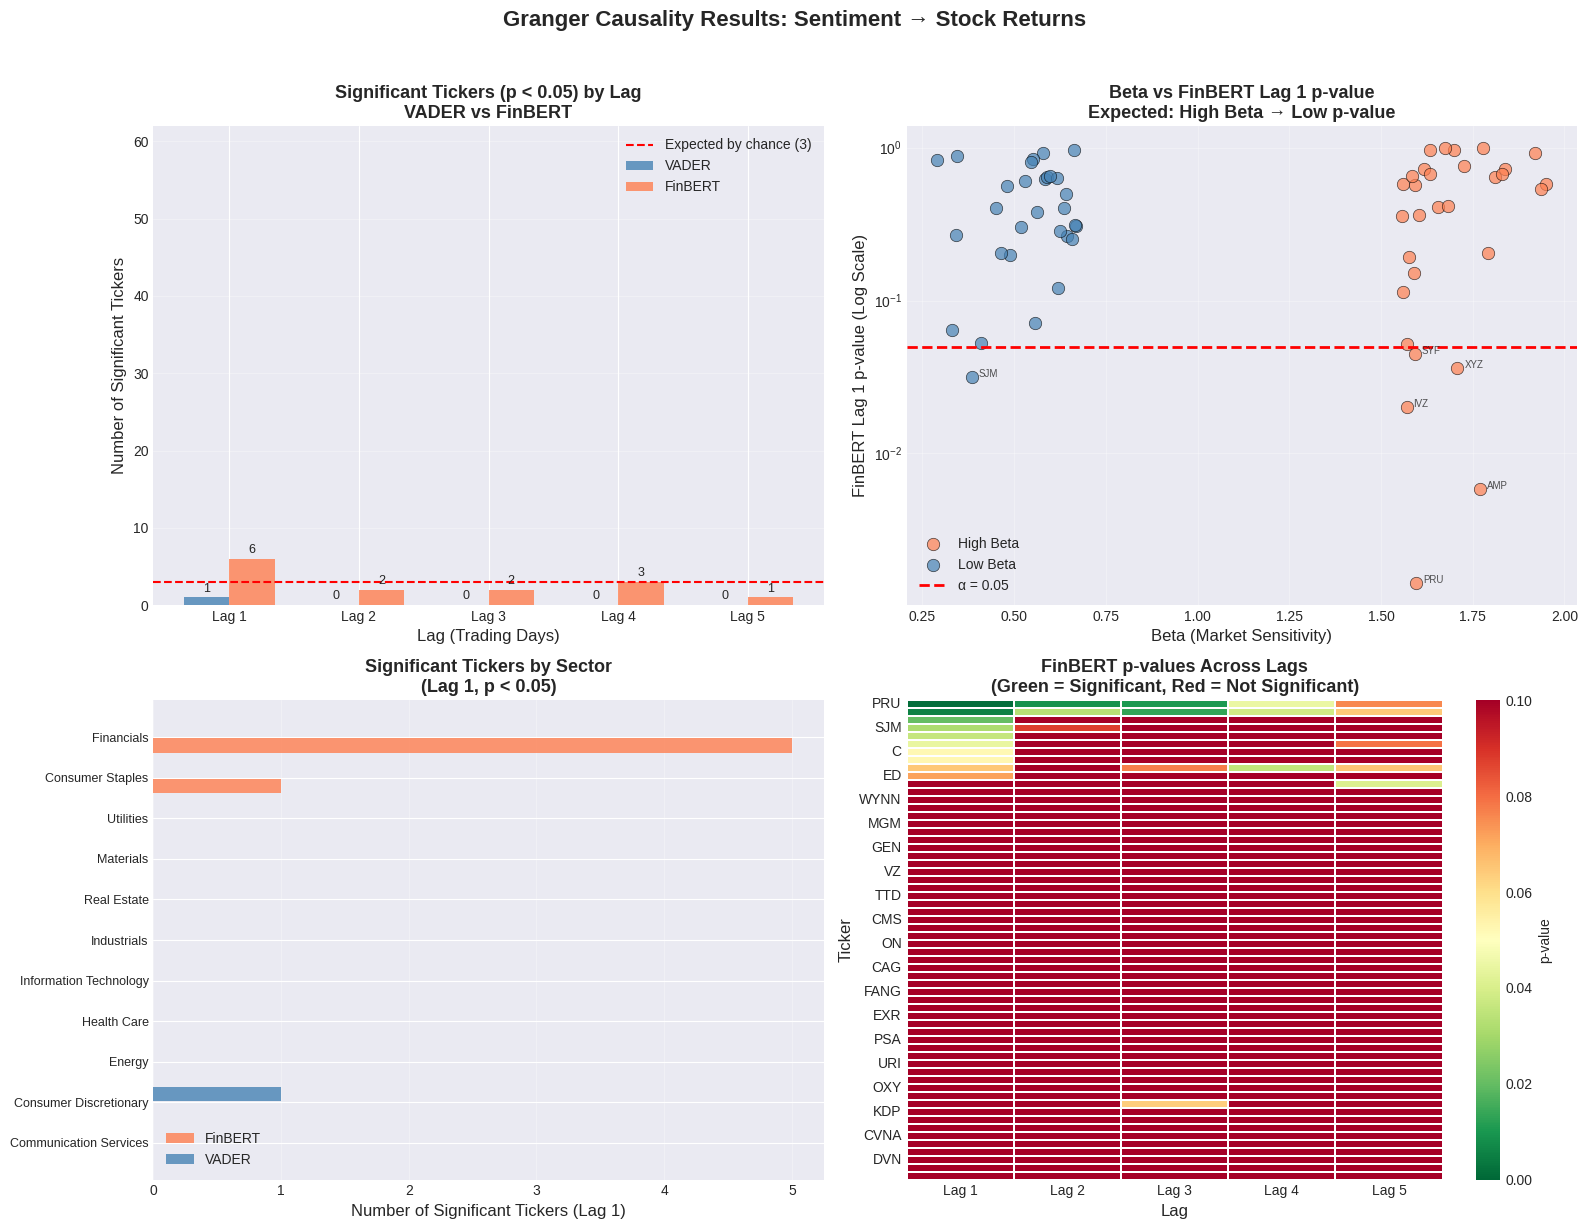

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Granger Causality Results: Sentiment → Stock Returns',
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Bar Chart - Significant tickers (VADER vs FinBERT)
ax1 = axes[0, 0]
lags_to_plot = [1, 2, 3, 4, 5]
vader_counts = [results_df[f'VADER_p_lag{l}'].lt(ALPHA).sum() for l in lags_to_plot]
finbert_counts = [results_df[f'FinBERT_p_lag{l}'].lt(ALPHA).sum() for l in lags_to_plot]

x = np.arange(len(lags_to_plot))
width = 0.35
bars1 = ax1.bar(x - width/2, vader_counts, width, label='VADER', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, finbert_counts, width, label='FinBERT', color='coral', alpha=0.8)

ax1.set_xlabel('Lag (Trading Days)', fontsize=12)
ax1.set_ylabel('Number of Significant Tickers', fontsize=12)
ax1.set_title(f'Significant Tickers (p < {ALPHA}) by Lag\nVADER vs FinBERT', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Lag {l}' for l in lags_to_plot])
ax1.axhline(y=total * ALPHA, color='red', linestyle='--', linewidth=1.5,
            label=f'Expected by chance ({int(total * ALPHA)})')
ax1.legend(fontsize=10)
ax1.set_ylim(0, total + 2)
ax1.bar_label(bars1, padding=2, fontsize=9)
ax1.bar_label(bars2, padding=2, fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Scatter - Beta vs FinBERT p-value (Log Scale)
ax2 = axes[0, 1]
colors_map = {'High Beta': 'coral', 'Low Beta': 'steelblue'}
for group, group_df in results_df.groupby('Beta_Group'):
    ax2.scatter(
        group_df['Beta'],
        group_df['FinBERT_p_lag1'],
        c=colors_map[group],
        label=group,
        alpha=0.7,
        s=80,
        edgecolors='black',
        linewidths=0.5
    )

ax2.axhline(y=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')
ax2.set_yscale('log')
ax2.set_xlabel('Beta (Market Sensitivity)', fontsize=12)
ax2.set_ylabel('FinBERT Lag 1 p-value (Log Scale)', fontsize=12)
ax2.set_title('Beta vs FinBERT Lag 1 p-value\nExpected: High Beta → Low p-value', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

for _, row in results_df[results_df['FinBERT_sig_lag1']].iterrows():
    ax2.annotate(row['Ticker'], (row['Beta'], row['FinBERT_p_lag1']),
                 textcoords='offset points', xytext=(5, 0), fontsize=7, alpha=0.8)

# Plot 3: Sector breakdown of significant results
ax3 = axes[1, 0]
sector_results = results_df.groupby('Sector').agg(
    total=('Ticker', 'count'),
    finbert_sig=('FinBERT_sig_lag1', 'sum'),
    vader_sig=('VADER_sig_lag1', 'sum')
).reset_index()
sector_results['finbert_rate'] = sector_results['finbert_sig'] / sector_results['total']
sector_results = sector_results.sort_values('finbert_rate', ascending=True)

y_pos = np.arange(len(sector_results))
ax3.barh(y_pos - 0.2, sector_results['finbert_sig'], height=0.35, label='FinBERT', color='coral', alpha=0.8)
ax3.barh(y_pos + 0.2, sector_results['vader_sig'], height=0.35, label='VADER', color='steelblue', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(sector_results['Sector'], fontsize=9)
ax3.set_xlabel('Number of Significant Tickers (Lag 1)', fontsize=12)
ax3.set_title('Significant Tickers by Sector\n(Lag 1, p < 0.05)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: P-value heatmap across lags (FinBERT)
ax4 = axes[1, 1]
finbert_pval_cols = [f'FinBERT_p_lag{l}' for l in range(1, MAX_LAGS + 1)]
heatmap_data = results_df.set_index('Ticker')[finbert_pval_cols].copy()
heatmap_data.columns = [f'Lag {l}' for l in range(1, MAX_LAGS + 1)]

heatmap_data = heatmap_data.sort_values('Lag 1')

sns.heatmap(
    heatmap_data,
    ax=ax4,
    cmap='RdYlGn_r',
    vmin=0, vmax=0.1,
    annot=len(heatmap_data) <= 30,
    fmt='.2f',
    linewidths=0.3,
    cbar_kws={'label': 'p-value'}
)
ax4.set_title('FinBERT p-values Across Lags\n(Green = Significant, Red = Not Significant)',
              fontsize=13, fontweight='bold')
ax4.set_xlabel('Lag', fontsize=12)
ax4.set_ylabel('Ticker', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(plots, 'granger_causality_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Save Output

In [50]:
results_simplified = results_df.copy()

spy_simplified = {
    'Ticker': 'SPY',
    'Sector': 'Market Benchmark',
    'Beta_Group': 'Market',
    'VADER_p_lag1': market_vader_pvals.get(1, np.nan),
    'FinBERT_p_lag1': market_finbert_pvals.get(1, np.nan),
    'VADER_p_lag2': market_vader_pvals.get(2, np.nan),
    'FinBERT_p_lag2': market_finbert_pvals.get(2, np.nan)
}

results_simplified = pd.concat(
    [results_simplified, pd.DataFrame([spy_simplified])],
    ignore_index=True
)

output_df = pd.DataFrame({
    'Ticker': results_simplified['Ticker'],
    'Sector': results_simplified['Sector'],
    'Beta_Group': results_simplified['Beta_Group'],
    'VADER_Lag1_P': results_simplified['VADER_p_lag1'],
    'FinBERT_Lag1_P': results_simplified['FinBERT_p_lag1'],
    'Is_Significant': results_simplified['FinBERT_p_lag1'] < ALPHA
})

output_df['VADER_Lag2_P'] = results_simplified['VADER_p_lag2']
output_df['FinBERT_Lag2_P'] = results_simplified['FinBERT_p_lag2']

output_path = os.path.join(data_processed, 'granger_causality_results.csv')
output_df.to_csv(output_path, index=False)

print(f'  Granger causality results saved (simplified format):')
print(f'  {output_path}')
print(f'  Rows: {len(output_df):,} (60 stocks + SPY)')
print(f'  Columns: {list(output_df.columns)}')
print(f'\nSample output:')
print(output_df.head(10))

  Granger causality results saved (simplified format):
  /content/drive/MyDrive/market-sentiment-impact-analysis/data/processed/granger_causality_results.csv
  Rows: 61 (60 stocks + SPY)
  Columns: ['Ticker', 'Sector', 'Beta_Group', 'VADER_Lag1_P', 'FinBERT_Lag1_P', 'Is_Significant', 'VADER_Lag2_P', 'FinBERT_Lag2_P']

Sample output:
  Ticker                  Sector Beta_Group  VADER_Lag1_P  FinBERT_Lag1_P  Is_Significant  VADER_Lag2_P  FinBERT_Lag2_P
0    AEP               Utilities   Low Beta        0.3564          0.6269           False        0.1001          0.6530
1    AMP              Financials  High Beta        0.4619          0.0058            True        0.7845          0.0333
2    APA                  Energy  High Beta        0.9882          0.5789           False        0.6257          0.7574
3     BA             Industrials  High Beta        0.4620          0.4082           False        0.8406          0.8531
4      C              Financials  High Beta        0.9513        